## What I did in this notebook:
- read all material and **learnt** it
- improved **binary classification** model
- make a small **summary for each model** in the material

<h1>ML basics</h1>
Deep learning works by performing large‑scale numerical computation on tensor (scalars, vectors, matrices and higher‑dimensional arrays). Getting comfortable with shape, rank, dtype and a few core operations (indexing, broadcasting, matmul, reductions) prevents most bugs when building models.

Import TensorFlow (GPU/CPU numerical engine + deep learning library) and NumPy (general numerical Python library). Print the TF version. Some behaviors (e.g., default dtypes) can vary across versions.

In [1]:
import tensorflow as tf
import numpy as np

print("TF:", tf.__version__)

TF: 2.20.0


Rank = number of axes (dimensions).  
scalar has rank 0 (shape=()) > a single number;  
vector rank 1 (shape=(3,));  
matrix rank 2 (shape=(2,2));  
tensor rank 3 (shape=(2,2,1)).  
Shape = size along each axis (batch, height, width...).

  
Your models understand only numbers and shapes. 

In [2]:
# 1) Scalars, vectors, matrices, tensors
scalar = tf.constant(7)  # rank-0
vector = tf.constant([10, 20, 30]) # rank-1
matrix = tf.constant([[1., 2.], [3., 4.]])  # rank-2
tensor  = tf.constant([[[1],[2]], [[3],[4]]]) # rank-3 (2x2x1)

print(scalar.shape, vector.shape, matrix.shape, tensor.shape)

() (3,) (2, 2) (2, 2, 1)


<i>Extra task:</i><br>
What’s the rank/shape of an RGB image with 32 images 64×64 pixels?

In [3]:
img_batch = tf.zeros([32, 64, 64, 3])  # 32 images, 64×64, RGB
print(img_batch.shape, img_batch.ndim) # (32, 64, 64, 3), rank=4

(32, 64, 64, 3) 4


tf.zeros([32, 64, 64, 3]) creates a new tensor of the given shape filled with zeros. In the context of images 0 means no intensity > a completely black pixel.<br><br>
So img_batch is a batch of 32 solid‑black images, each 64×64 with 3 color channels.

In [4]:
# 2) Dtypes and casting
x = tf.constant([1.7, 7.4]) # float32 default
y = tf.constant([7, 10]) # int32 default
x16 = tf.cast(x, tf.float16) # reduced precision floats
y32 = tf.cast(y, tf.float32) # cast ints → floats

A dtype (data type) tells TensorFlow what kind of numbers a tensor stores, e.g., float32, float16, int32, or bool. It’s one of the three core properties of a tensor alongside shape and rank. The dtype you choose affects memory use and numerical precision, so it has practical consequences for speed and stability.
<br><br>
Casting changes dtype without changing shape. float16 halves memory but reduces precision. Good for speed on certain GPUs.

In [5]:
# 3) Indexing and shaping
rank2 = tf.constant([[10, 7], [3, 4]])
last_col = rank2[:, -1] # column slice
expanded = tf.expand_dims(rank2, -1) # add channel-like axis
squeezed = tf.squeeze(expanded, axis=-1)

: picks all rows. 
-1 selects the last column. last_col has shape (2,).

<b>Reshaping:</b>

expand_dims(..., -1) adds a new axis at the end: (2,2) > (2,2,1).<br>
squeeze(..., axis=-1) removes a size‑1 axis: back to (2,2).

In [6]:
# 4) Broadcasting & basic ops
A = tf.constant([[10., 7.], [3., 4.]])
print("A+10:\n", A + 10)
print("A*2:\n", A * 2)

A+10:
 tf.Tensor(
[[20. 17.]
 [13. 14.]], shape=(2, 2), dtype=float32)
A*2:
 tf.Tensor(
[[20. 14.]
 [ 6.  8.]], shape=(2, 2), dtype=float32)


Basic ops: +, * operate per position. This is different from matrix multiplication (tf.matmul).

Matmul rule: For A @ B, the inner dimensions must match: (m×n) @ (n×p) -> (m×p). So you transpose Y (from (3×2) to (2×3)) to make 2 match 2.<br><br>
Matrix multiplication is central to neural networks. 

In [7]:
# 5) Matrix multiplication rules (inner dims match)
X = tf.constant([[1, 2], [3, 4], [5, 6]], dtype=tf.float32)  # (3x2)
Y = tf.constant([[7, 8], [9, 10], [11, 12]], dtype=tf.float32) # (3x2)
XtY = tf.matmul(X, tf.transpose(Y))     # (3x2) @ (2x3) -> (3x3)

In [8]:
# 6) Aggregations
E = tf.constant(np.random.randint(0, 100, size=10))
print("min:", tf.reduce_min(E).numpy(),
      "max:", tf.reduce_max(E).numpy(),
      "mean:", tf.reduce_mean(tf.cast(E, tf.float32)).numpy(),
      "sum:", tf.reduce_sum(E).numpy())


min: 0 max: 81 mean: 34.5 sum: 345


<b>Extra example  of why should we change int to float:</b>

In [9]:

M = tf.constant([[1., 2.], [3., 4.]])  # (2,2)
print(tf.reduce_mean(M, axis=0).numpy())  # column means -> [2., 3.]
print(tf.reduce_mean(M, axis=1).numpy())  # row means    -> [1.5, 3.5]

[2. 3.]
[1.5 3.5]


In [10]:
# 7) One-hot encoding
idx = tf.constant([0, 1, 2, 3])
oh  = tf.one_hot(idx, depth=4)

Each integer label becomes a vector of length depth; only the index position is 1, others 0. Example:<br>
0 -> [1,0,0,0]<br>
1 -> [0,1,0,0]

In [11]:
labels = tf.constant([2, 0, 1])
print(tf.one_hot(labels, depth=3).numpy())

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


You can convert NumPy arrays <-> TensorFlow tensors easily.

In [12]:

# 8) NumPy interop
arr = np.array([3., 7., 10.])
t   = tf.constant(arr) # NumPy -> Tensor
back_to_np = t.numpy() # Tensor -> NumPy

print("OK")

OK


<h2>Regression model</h2><br>
The standard Keras workflow: Create -> Compile -> Fit -> Evaluate -> Predict -> Visualize.<br><br>
Separate train/test to measure generalization instead of memorization.

We use Matplotlib for visualization. 

In [13]:
#import tensorflow as tf
#import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # for splitting data into train/test sets randomly

In [14]:
# Synthetic linear data
X = np.arange(-20, 21, 2, dtype=np.float32).reshape(-1, 1)  # [-20., -18., ..., 20.], create 1D array, and make it float32. reshape  for sklearn compatibility
y = X + 10

<img src="Screenshot_function.png" alt="y=X + 10">

Split material, first 20 points for training, remaining for testing.<br><br>
Split to evaluate on data not seen during training to estimate generalization (how well the learned rule applies to new inputs).

In [15]:
# Train/test split (simple)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Форма X_train: {X_train.shape}") # Должно быть (16 или 17, 1)
print(f"Количество образцов в X_train: {len(X_train)}") # 16 или 17 - больше одного!

Форма X_train: (16, 1)
Количество образцов в X_train: 16


Read more: <a href="https://keras.io/guides/sequential_model/">Sequential model</a><br><br>
A Sequential model is Keras’s model type for a single straight pipeline: one input > layers in order > one output. It’s ideal whenever your architecture is a plain stack (no branches/merges). This includes simple regression or classification on a single input vector and single input image pipelines. 

If the task has multiple inputs (e.g., image + numeric features) or needs branching/merging, switch to the Functional API. With Functional, you can build separate layer branches, an MLP (Dense) branch for numeric features and a CNN (Conv2D/MaxPool2D) branch for images. Then merge their features (e.g., Concatenate) and finish with a linear Dense output for regression (e.g. house price depending on size + photo).

A layer takes one or more tensors in and outputs one or more tensors after applying a computation (its call method). It also holds state (weights) that training updates. Layers are the basic building blocks you stack to form models. 

API in this case means a set of classes and methods you call to build neural networks.

In [16]:
# 1) CREATE
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)  # linear output for regression
])

A loss function turns your model’s mistakes into one number so the training loop knows how “wrong” the model is right now. Keras needs this number to decide how to adjust the weights on the next step. Without a loss, the model has no target to improve.
Why we need it (practically):

Gives the optimizer a target. During model.fit, Keras computes the loss on each batch and the optimizer uses it to nudge the weights to make that number smaller next time.

Enables training with one line. model.compile(loss=..., optimizer=..., metrics=...) wires everything so Keras can run the built‑in training loop. 
Lets you compare and monitor. You can watch training vs. validation loss to see if you’re improving, plateauing, or overfitting.

In [17]:
# 2) COMPILE
model.compile(
    loss="mae",
    optimizer="adam",
    metrics=["mae"]
)

model.fit(...) runs Keras’s built‑in training loop. On each epoch, the model makes predictions on batches of X_train, computes the loss against y_train, and the optimizer updates the weights to try to reduce that loss next time. The call returns a History object that contains per‑epoch logs (e.g., loss) in history.history.
epochs=200: “Try the whole dataset 200 times.” More epochs can help if the model hasn’t converged yet—but watch validation to avoid overfitting. 
<br><br>
verbose=0: hides per‑epoch printing. Use verbose=1 to show an epoch‑by‑epoch progress line, or verbose=2 to show one summary line per epoch.
<br><br>
If you want training to stop automatically when improvement stalls, add callbacks like EarlyStopping (optionally restoring the best weights). This is standard practice in Keras. 

In [18]:
# 3) FIT
history = model.fit(X_train, y_train, epochs=200, verbose=1)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - loss: 15.8564 - mae: 15.8564
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 15.8474 - mae: 15.8474
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 15.8384 - mae: 15.8384
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 15.8294 - mae: 15.8294
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 15.8204 - mae: 15.8204
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 15.8114 - mae: 15.8114
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 15.8024 - mae: 15.8024
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 15.7934 - mae: 15.7934
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 15.7844 - mae: 15.7844
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 15.7754 - mae: 15.7754
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 15.7664 - mae: 15.7664
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 15.7574 - mae: 15.7574
Epoch 13/200
1/1 ━━━━━━━

model.evaluate(...) runs the model on unseen test data and computes the loss and any metrics you set in compile. This measures generalization, not training progress.
<br><br> 
For a model compiled with a single metric (metrics=["mae"]), evaluate returns two numbers: [loss, metric]. Because here the loss is also "mae", you’ll typically see very similar values for loss and mae. Printing “Test MAE:” gives an accuracy number in target units.
<br><br>
Performance should be judged on data not used during training. This is how we check the model learned the rule (here, y = x + 10) rather than memorizing specific points.

In [19]:
# Evaluate
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MAE:", mae)


Test MAE: 15.940478324890137


model.predict(...): produces outputs for new inputs without changing weights. We squeeze to make the array 1‑D for plotting.
<br><br>
Why the plot: Numbers summarize; plots explain. Showing true test points (green) and predictions (red) over the same X_test makes it visually clear whether the learned line matches the underlying rule. This aligns with the teaching guidance in your material—visual inspection reveals bias and systematic mismatches better than a single average number.
<br><br>
What to expect here: If training went well, the red predicted points should lie close to the green test points along a line with slope = 1 and intercept = 10 (the model has learned y = x + 10). Your evaluate step’s Test MAE should be small, and the scatter should show tight overlap

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


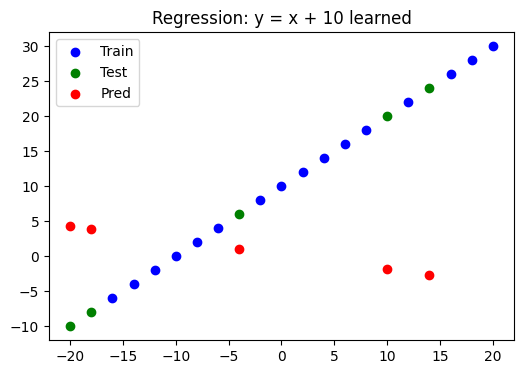

In [20]:
# Predict and visualize
y_pred = model.predict(X_test).squeeze()

plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, c='b', label='Train')
plt.scatter(X_test,  y_test,  c='g', label='Test')
plt.scatter(X_test,  y_pred,  c='r', label='Pred')
plt.legend(); plt.title("Regression: y = x + 10 learned")
plt.show()

HOMEWORK: Fix the regression model

How I fixed it:
1. I have splited train/test data randomply, because previously model was tested on numbers 18 and 20, which is out of range of training.
2. I have added flatten layer, so it would make (batch, 1) to (batch,), but it didn't helped
3. delete flatten layer, and trying optimazer adam


<h1>Classification</h1>

This is binary classification model. It classificats points ether in or out of cicle.
- it uses 1000 samples(1000 points some in some out of circle)
- data is splited 80/20, 80 - train, 20 - test. Model is randomly choosing with data will be test/train. But it is controlled by `random_state=42`.
- The model has 4 layers:
    - input layer with shape (2,) because each point has two coordinates (x and y).
    - hidden layer with 16 neurons and ReLU activation.
    - hidden layer with 16 neurons and ReLU activation.
    - output layer with 1 neuron and sigmoid activation.
- loss function is used binary_crossentropy
- optimazer adam with learning rate 0.01
- 25 epochs 

Test accuracy: 1.000


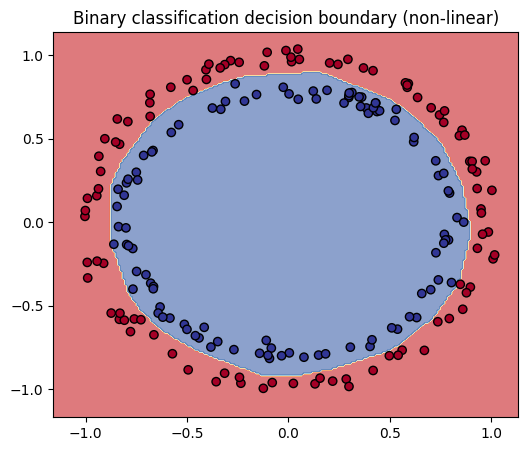

In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Non-linear separable data
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

# 1) CREATE (use non-linear activations + sigmoid output)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(X_train, y_train, epochs=25, verbose=0)

# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Visualize decision boundary
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 200),
                     np.linspace(X[:,1].min()-0.1, X[:,1].max()+0.1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, (probs>0.5).astype(int), cmap=plt.cm.RdYlBu, alpha=0.6)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap=plt.cm.RdYlBu, edgecolor='k')
plt.title("Binary classification decision boundary (non-linear)")
plt.show()


This is a multi-class image classification model that predicts clothing categories from the Fashion-MNIST dataset
- the dataset contains `70,000 grayscale images` of clothing items (60,000 for training and 10,000 for testing)
- each image has a size of `28 × 28` pixels
- pixel values are normalized from `[0,255]` to `[0,1]` to improve training performance
- the model has 4 layers:
    - input layer with shape `(28,28)`
    - flatten layer converting the image to a vector of 784 values
    - dense hidden layer with 128 neurons and ReLU activation
    - output layer with 10 neurons and Softmax activation
- the loss function is `sparse_categorical_crossentropy`, which is used for multi-class classification with integer labels
- the optimizer is `adam`
- the model is trained for `10 epochs`, with 10% of the training data used for validation

Test accuracy: 0.8774999976158142
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


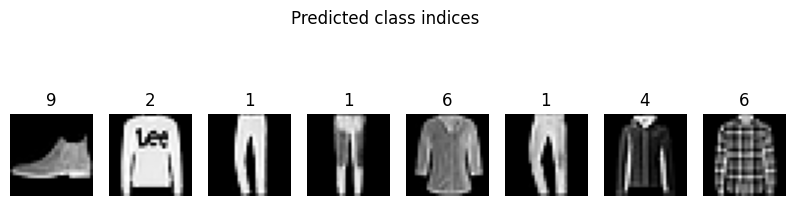

In [22]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32")/255.0
x_test  = x_test.astype("float32")/255.0

# 1) CREATE (flatten → Dense ReLU → Dense softmax)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# 2) COMPILE
model.compile(
    loss="sparse_categorical_crossentropy",  # labels are ints, not one-hot
    optimizer="adam",
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(x_train, y_train, epochs=10, validation_split=0.1, verbose=0)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)

# Show a few preds
preds = model.predict(x_test[:8]).argmax(axis=1)
plt.figure(figsize=(10,3))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(int(preds[i]))
    plt.axis('off')
plt.suptitle("Predicted class indices"); plt.show()


This is a binary image classification model based on the Fashion-MNIST dataset. It classifies images as either Sneaker (class 7) or Ankle boot (class 9)
- the dataset is filtered to keep only two classes: 7 (Sneaker) and 9 (Ankle boot)
- images are `28×28` grayscale and are normalized to the range [0,1]
- the labels are converted to binary values: 1 for class 9 (Ankle boot) and 0 for class 7 (Sneaker)
- the model is a small `Convolutional Neural Network` (CNN) with layers:
    - input layer `(28,28,1)`
    - `conv2D` (16 filters, ReLU) + MaxPooling
    - `conv2D` (32 filters, ReLU) + MaxPooling
    - flatten layer
    - dense layer (64 neurons, ReLU)
    - output layer (1 neuron, Sigmoid)
- the loss function is `binary_crossentropy` because this is a binary classification problem
- the optimizer used is `adam`
- the model is trained for `5 epochs` with 10% of training data used for validation

In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Use Fashion-MNIST but map 2 classes to a binary task (e.g., class 9=Ankle boot vs 7=Sneaker)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
# Keep only classes 7 and 9
train_mask = np.isin(y_train, [7, 9])
test_mask  = np.isin(y_test,  [7, 9])

x_train = x_train[train_mask][..., None]/255.0
y_train = (y_train[train_mask] == 9).astype(np.float32)  # 1 if class 9 else 0
x_test  = x_test[test_mask][..., None]/255.0
y_test  = (y_test[test_mask] == 9).astype(np.float32)

# 1) CREATE (small CNN)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1, verbose=0)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)


KeyboardInterrupt: 

This is a multi-class image classification model using the CIFAR-10 dataset, but only three classes (0, 1, 2) are kept. The model learns to classify images into three categories.

- the dataset `CIFAR-10` contains `32×32 color images` (RGB).
- only classes 0, 1, and 2 are used, so the problem becomes a `3-class classification task`.
- images are normalized to the range `[0,1]` to improve training stability.
- the model is a small `Convolutional Neural Network` (CNN) with layers:
    - conv2D (32 filters, 3×3, ReLU) + MaxPooling
    - conv2D (64 filters, 3×3, ReLU) + MaxPooling
    - conv2D (128 filters, 3×3, ReLU) + MaxPooling
    - flatten layer
    - dense layer (64 neurons, ReLU)
    - output layer (3 neurons, Softmax) for the three classes
- the loss function is `sparse_categorical_crossentropy`, which is used for multi-class classification with integer labels.
- the optimizer is `adam`.
- the model is trained for 5 epochs with batch size 64, and 10% of the training data is used for validation.

In [ ]:

import tensorflow as tf
from tensorflow.keras import layers, models

# --- Data ---
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Keep classes 0,1,2 only
mask_train = (y_train < 3).flatten()
mask_test  = (y_test  < 3).flatten()
x_train = x_train[mask_train].astype("float32")/255.0
y_train = y_train[mask_train].flatten()
x_test  = x_test[mask_test].astype("float32")/255.0
y_test  = y_test[mask_test].flatten()

# --- Very small CNN model ---
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(32,32,3)), # filter size 3*3
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# --- Train ---
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# --- Evaluate ---
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy (tiny CNN):", acc)


C:\Users\rolan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.7222 - loss: 0.6480 - val_accuracy: 0.7920 - val_loss: 0.5373
Epoch 2/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8344 - loss: 0.4191 - val_accuracy: 0.8720 - val_loss: 0.3528
Epoch 3/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8684 - loss: 0.3377 - val_accuracy: 0.8960 - val_loss: 0.2987
Epoch 4/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8861 - loss: 0.2902 - val_accuracy: 0.9033 - val_loss: 0.2790
Epoch 5/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8996 - loss: 0.2581 - val_accuracy: 0.9060 - val_loss: 0.2567
Test accuracy (tiny CNN): 0.890666663646698


This is a multi-class classification model trained on a synthetic dataset of small 8×8 grayscale images. The goal is to classify simple patterns: vertical bar, horizontal bar, or diagonal line.

- the dataset is artificially generated, with 600 images total (200 per class).
- each image is `8×8 pixels` with 1 grayscale channel, and small Gaussian noise is added to make the task less trivial.
- the dataset is shuffled and split 80/20 into training and test sets.
- the model is a small `MLP (Multilayer Perceptron)` with layers:
    - flatten layer converting the image from (8,8,1) to a vector of 64 values
    - dense layer with 8 neurons and ReLU activation
    - output layer with 3 neurons and Softmax activation for the three classes
- the loss function is `sparse_categorical_crossentropy`, used for multi-class classification with integer labels.
- the optimizer is `adam`.
- the model is trained for `8 epochs` with batch size 32, and 20% of the training data is used for validation.

Train: (480, 8, 8, 1) (480,)
Test:  (120, 8, 8, 1) (120,)


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_27 (Flatten)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 547 (2.14 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3255 - loss: 1.0332 - val_accuracy: 0.3333 - val_loss: 0.9581
Epoch 2/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3255 - loss: 0.8919 - val_accuracy: 0.3333 - val_loss: 0.8285
Epoch 3/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4271 - loss: 0.7717 - val_accuracy: 0.7708 - val_loss: 0.7181
Epoch 4/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9766 - loss: 0.6676 - val_accuracy: 1.0000 - val_loss: 0.6234
Epoch 5/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.5828 - val_accuracy: 1.0000 - val_loss: 0.5502
Epoch 6/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.5155 - val_accuracy: 1.0000 - val_loss: 0.4904
Epoch 7/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.4610 - val_accuracy: 1.0000 - val_loss: 0.4416
Epoch 8/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.4148 - val_accuracy: 1.0000 - val_loss: 0.3976

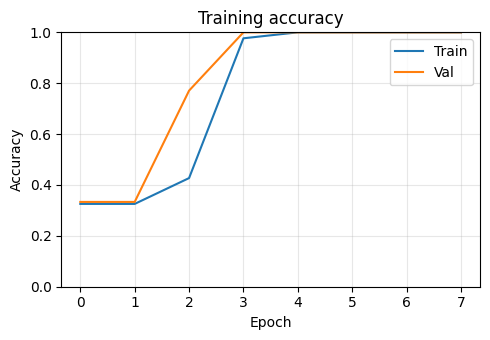

Test accuracy: 1.000
You must install pydot (`pip install pydot`) for `plot_model` to work.


FileNotFoundError: No such file or directory: 'mlp_tiny.png'

FileNotFoundError: No such file or directory: 'mlp_tiny.png'

<IPython.core.display.Image object>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

np.random.seed(0)
tf.random.set_seed(0)

# Simple 8x8 grayscale data

def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32)
    if label == 0:         # vertical bar
        img[:, 3] = 1.0
    elif label == 1:       # horizontal bar
        img[3, :] = 1.0
    else:                  # diagonal
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Shuffle + split
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)

# Small MLP model
model = keras.Sequential([
    layers.Flatten(input_shape=(8, 8, 1)),  # (None, 64) — no params
    layers.Dense(8, activation="relu"),     # 64*8 + 8 = 520 params
    layers.Dense(3, activation="softmax")   # 8*3 + 3 = 27 params
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# Train
history = model.fit(
    x_train, y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Plot accuracy (train vs val)
plt.figure(figsize=(5,3.5))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Training accuracy")
plt.tight_layout()
plt.show()

# Evaluate on test set
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Plot the model diagram
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display
plot_model(model, to_file="mlp_tiny.png")
display(Image("mlp_tiny.png"))


This is a `multi-class classification` model trained on a synthetic dataset of `8×8 grayscale images`. The task is to classify simple patterns: vertical bar, horizontal bar, or diagonal line
- the dataset is artificially generated, containing 600 images total (200 per class)
- each image is `8×8 pixels` with 1 grayscale channel, and small random noise is added to make the classification task more realistic
- the dataset is shuffled and split 80/20 into training and test sets
- the model is built using the `Functional API` and has `parallel branches`:
    - input layer (8,8,1)
    - flatten layer converting the image into 64 features
    - two parallel Dense layers (each with 4 neurons and ReLU activation)
    - the outputs of the two branches are concatenated
    - output layer with 3 neurons and Softmax activation for the three classes
the loss function is sparse_categorical_crossentropy, used for multi-class classification with integer labels
the optimizer is `adam`
the model is trained for `8 epochs` with batch size 32, and 20% of the training data is used for validation

Train: (480, 8, 8, 1) (480,)
Test:  (120, 8, 8, 1) (120,)


Model: "tiny_parallel_mlp"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 8, 8, 1)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 64)        │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchA_dense       │ (None, 4)         │        260 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchB_dense       │ (None, 4)         │        260 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 8)         │          0 │ branchA_dense[0]… │
│ (Concatenate)       │                   │            │ branchB_dense[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │         27 │ concat[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 547 (2.14 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.0286 - loss: 1.2053 - val_accuracy: 0.1562 - val_loss: 1.1524
Epoch 2/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2839 - loss: 1.1050 - val_accuracy: 0.3021 - val_loss: 1.0611
Epoch 3/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3359 - loss: 1.0195 - val_accuracy: 0.3333 - val_loss: 0.9808
Epoch 4/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5260 - loss: 0.9484 - val_accuracy: 0.9062 - val_loss: 0.9200
Epoch 5/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9297 - loss: 0.8931 - val_accuracy: 0.9583 - val_loss: 0.8682
Epoch 6/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9583 - loss: 0.8415 - val_accuracy: 0.9792 - val_loss: 0.8178
Epoch 7/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9922 - loss: 0.7911 - val_accuracy: 0.9896 - val_loss: 0.7692
Epoch 8/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9974 - loss: 0.7425 - val_accuracy: 1.0000 - val_loss: 0.7227

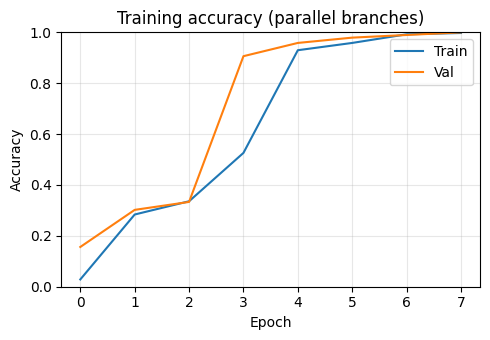

Test accuracy: 0.983
You must install pydot (`pip install pydot`) for `plot_model` to work.


FileNotFoundError: No such file or directory: 'parallel_mlp.png'

FileNotFoundError: No such file or directory: 'parallel_mlp.png'

<IPython.core.display.Image object>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

np.random.seed(0)
tf.random.set_seed(0)

# Simple 8x8 grayscale data
def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32)
    if label == 0:         # vertical bar
        img[:, 3] = 1.0
    elif label == 1:       # horizontal bar
        img[3, :] = 1.0
    else:                  # diagonal
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Shuffle + split
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)

# Parallel-branches MLP (Functional API)
inputs = keras.Input(shape=(8, 8, 1), name="input")
x = layers.Flatten(name="flatten")(inputs)          # (None, 64) — params: 0

# Branch A: Dense(4)
branch_a = layers.Dense(4, activation="relu", name="branchA_dense")(x)  # params: 64*4 + 4 = 260

# Branch B: Dense(4)
branch_b = layers.Dense(4, activation="relu", name="branchB_dense")(x)  # params: 64*4 + 4 = 260

# Merge (concatenate)
merged = layers.Concatenate(name="concat")([branch_a, branch_b])

# Output: Dense(3)
outputs = layers.Dense(3, activation="softmax", name="output")(merged)

model = keras.Model(inputs, outputs, name="tiny_parallel_mlp")

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# Train
history = model.fit(
    x_train, y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Plot accuracy
plt.figure(figsize=(5,3.5))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Training accuracy (parallel branches)")
plt.tight_layout()
plt.show()

# Evaluate on test set
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Plot the model diagram
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display
plot_model(model, to_file="parallel_mlp.png")
display(Image("parallel_mlp.png"))


This is a multi-class classification model trained on a synthetic dataset of 8×8 grayscale images. The task is to classify simple patterns: vertical bar, horizontal bar, or diagonal line.

- the dataset is artificially generated, containing `600 images` (200 per class)
- each image is `8×8 pixels` with `1 grayscale channel`, and small random noise is added to make the task less trivial
- the dataset is shuffled and split 80/20 into training and test sets.
- the model is a small `MLP (Multilayer Perceptron)` with layers:
    - flatten layer converting the image from `(8,8,1)` to a vector of 64 values
    - dense layer with `8 neurons` and ReLU activation
    - output layer with `3 neurons` and Softmax activation for the three classes
- the loss function is `sparse_categorical_crossentropy`, used for multi-class classification with integer labels
- the optimizer is `adam`
- the model is trained for 6 epochs with batch size 32, and 20% of the training data is used for validation

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

np.random.seed(0)
tf.random.set_seed(0)

# Simple 8x8 grayscale data
def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32)
    if label == 0:         # vertical bar
        img[:, 3] = 1.0
    elif label == 1:       # horizontal bar
        img[3, :] = 1.0
    else:                  # diagonal
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Shuffle + split
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)

# MLP model 
model = keras.Sequential([
    layers.Flatten(input_shape=(8, 8, 1)),  # (None, 64) — 0 params
    layers.Dense(8, activation="relu"),     # 64*8 + 8 = 520 params
    layers.Dense(3, activation="softmax")   # 8*3 + 3 = 27 params
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Train
history = model.fit(
    x_train, y_train,
    epochs=6,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Save to a .keras file
save_path = "miras_model.keras"
model.save(save_path)
print("Saved model to:", os.path.abspath(save_path))

Train: (480, 8, 8, 1) (480,)
Test:  (120, 8, 8, 1) (120,)
Epoch 1/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3438 - loss: 1.0169 - val_accuracy: 0.3958 - val_loss: 0.9347
Epoch 2/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5521 - loss: 0.8933 - val_accuracy: 0.6979 - val_loss: 0.8202
Epoch 3/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6693 - loss: 0.7881 - val_accuracy: 0.6979 - val_loss: 0.7272
Epoch 4/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7188 - loss: 0.7018 - val_accuracy: 0.8646 - val_loss: 0.6473
Epoch 5/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9792 - loss: 0.6261 - val_accuracy: 1.0000 - val_loss: 0.5764
Epoch 6/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.5585 - val_accuracy: 1.0000 - val_loss: 0.5135
Test accuracy: 1.000
Saved model to: c:\Users\rolan\Machine-Learning\miras_model.keras


This code demonstrates loading and using a previously saved neural network model to make predictions on the same synthetic dataset of 8×8 grayscale images
- the same synthetic dataset of 600 images (vertical bar, horizontal bar, diagonal line) is recreated with small random noise
- the dataset is shuffled and split 80/20 into training and test sets, matching the split used during training
- a previously trained model is loaded from the file miras_model.keras using `keras.models.load_model()`
- the model architecture is displayed using `model.summary()`
- the loaded model is evaluated on the test dataset to check its accuracy
- the model then predicts the classes of several test samples, producing probability outputs which are converted to predicted labels using argmax

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Recreate the same simple dataset
np.random.seed(0)
tf.random.set_seed(0)

def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32)
    if label == 0:
        img[:, 3] = 1.0
    elif label == 1:
        img[3, :] = 1.0
    else:
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Same split as before
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

# Load the saved .keras file
loaded_model = keras.models.load_model("miras_model.keras")
loaded_model.summary()

# Evaluate the loaded model
loss, acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Loaded model - test accuracy: {acc:.3f}")

# Predict a few samples
probs = loaded_model.predict(x_test[:5], verbose=0)  # shape: (5, 3)
preds = probs.argmax(axis=1)
print("Predictions:", preds)
print("True labels:", y_test[:5].tolist())

Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_28 (Flatten)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,643 (6.42 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,096 (4.29 KB)

Loaded model - test accuracy: 1.000
Predictions: [2 1 0 2 2]
True labels: [2, 1, 0, 2, 2]


## accuracy vs optimizer
- This function is used to understand which optimizer suits a certain model better based on accuracy. 
- Optimizers affect the learning speed and stability of the model. 
- This function creates a separate model for each optimizer, trains it on the same data, and then compares the accuracy results.

In [ ]:
# optimazers to compare
optimizers = [ 
    tf.keras.optimizers.SGD(),
    tf.keras.optimizers.Adam(),
    tf.keras.optimizers.RMSprop()
]

def optimizer_vs_accuracy(optimizers, x_train, y_train, x_test, y_test, epochs=5):

    results = {}

    for opt in optimizers: # loop through every optimizer
        model = tf.keras.Sequential([ # creating different model for fair comparison
            tf.keras.layers.Flatten(input_shape=(8,8,1)),
            tf.keras.layers.Dense(8, activation="relu"),
            tf.keras.layers.Dense(3, activation="softmax")
        ])

        # compile with a different optimizer
        model.compile(
            optimizer=opt,
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        # train model
        model.fit(x_train, y_train, epochs=epochs, verbose=0)

        # evaluate 
        loss, acc = model.evaluate(x_test, y_test, verbose=0)

        print(f"Optimizer: {opt} -> Accuracy: {acc:.3f}")

        results[str(opt)] = acc # store accuracy for this optimizer

    return results
# Compare optimizers
results = optimizer_vs_accuracy(
    optimizers,
    x_train,
    y_train,
    x_test,
    y_test,
    epochs=6
)

print(results)

Optimizer: <keras.src.optimizers.sgd.SGD object at 0x000001B53277B950> -> Accuracy: 0.642
Optimizer: <keras.src.optimizers.adam.Adam object at 0x000001B5328FB490> -> Accuracy: 1.000
Optimizer: <keras.src.optimizers.rmsprop.RMSprop object at 0x000001B532817650> -> Accuracy: 1.000
{'<keras.src.optimizers.sgd.SGD object at 0x000001B53277B950>': 0.6416666507720947, '<keras.src.optimizers.adam.Adam object at 0x000001B5328FB490>': 1.0, '<keras.src.optimizers.rmsprop.RMSprop object at 0x000001B532817650>': 1.0}
